<a href="https://colab.research.google.com/github/m2nwo079/global-challenger-2026/blob/main/02_module_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil, sqlite3, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/globalchallenger'
WORK = '/content/work'
DB   = f'{WORK}/data/db/criteo.db'

os.makedirs(f'{WORK}/data/db', exist_ok=True)
if not os.path.exists(DB):
    print('Copying DB from Drive...')
    shutil.copy(f'{BASE}/data/db/criteo.db', DB)

con = sqlite3.connect(DB)
con.execute('PRAGMA cache_size = -800000')
con.execute('PRAGMA temp_store = MEMORY')

plt.rcParams['savefig.dpi']  = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.unicode_minus'] = False

DAY = 86400
WINDOWS = {1: DAY, 7: 7*DAY, 14: 14*DAY, 30: 30*DAY}

print(pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table'", con))

Mounted at /content/drive
Copying DB from Drive...
                 name
0         attribution
1  attribution_sample


In [2]:
%%time
con.executescript("""
DROP TABLE IF EXISTS attributed;
CREATE TABLE attributed AS
SELECT conversion_id, campaign, timestamp, conversion_timestamp,
       click, click_pos, click_nb,
       conversion_timestamp - timestamp AS gap
FROM attribution
WHERE attribution = 1;
CREATE INDEX idx_attr_conv ON attributed (conversion_id);
""")
con.commit()

print(pd.read_sql_query("""
SELECT COUNT(*)                     AS rows,
       COUNT(DISTINCT conversion_id) AS conversions,
       SUM(CASE WHEN click = 0 THEN 1 ELSE 0 END) AS non_click_rows,
       MIN(gap) AS gap_min, MAX(gap) AS gap_max,
       MIN(click_pos) AS cpos_min, MAX(click_nb) AS cnb_max
FROM attributed
""", con).T)

print(pd.read_sql_query("""
SELECT COUNT(*) AS inconsistent FROM (
  SELECT conversion_id,
         COUNT(*)             AS n_rows,
         MIN(click_nb)        AS cnb_min,
         MAX(click_nb)        AS cnb_max,
         COUNT(DISTINCT click_pos) AS n_pos
  FROM attributed GROUP BY conversion_id
)
WHERE cnb_min <> cnb_max OR n_rows <> cnb_max OR n_pos <> n_rows
""", con))

                      0
rows             442424
conversions      236331
non_click_rows        0
gap_min               1
gap_max         2591969
cpos_min              0
cnb_max             165
   inconsistent
0         42264
CPU times: user 3.42 s, sys: 879 ms, total: 4.3 s
Wall time: 4.61 s


In [3]:
def rule_totals(w):
    q = f"""
    SELECT
      SUM(CASE WHEN click_pos = click_nb - 1 THEN 1 ELSE 0 END) AS last_click,
      SUM(CASE WHEN click_pos = 0            THEN 1 ELSE 0 END) AS first_click,
      COUNT(*)                                                  AS all_clicks,
      SUM(1.0 / click_nb)                                       AS uniform,
      COUNT(DISTINCT conversion_id)                             AS conv_in_window,
      COUNT(DISTINCT CASE WHEN click_pos = click_nb - 1
                          THEN conversion_id END)               AS conv_last_click,
      COUNT(DISTINCT CASE WHEN click_pos = 0
                          THEN conversion_id END)               AS conv_first_click
    FROM attributed WHERE gap <= {w}
    """
    d = pd.read_sql_query(q, con)
    d.insert(0, 'window_days', w // DAY)
    return d

tot = pd.concat([rule_totals(w) for w in WINDOWS.values()], ignore_index=True)
tot['share_of_all_conv'] = tot.conv_in_window / 236331
print(tot.to_string(index=False, float_format='%.1f'))

 window_days  last_click  first_click  all_clicks  uniform  conv_in_window  conv_last_click  conv_first_click  share_of_all_conv
           1      175249       131392      211497 148629.8          174977           174796            131129                0.7
           7      204235       171153      321428 186809.3          207855           203639            170725                0.9
          14      212114       190068      379053 202064.5          221132           211459            189543                0.9
          30      216528       216033      442424 216184.8          236331           215849            215351                1.0


In [4]:
def campaign_credit(w):
    q = f"""
    SELECT campaign,
      SUM(CASE WHEN click_pos = click_nb - 1 THEN 1 ELSE 0 END) AS last_click,
      SUM(CASE WHEN click_pos = 0            THEN 1 ELSE 0 END) AS first_click,
      COUNT(*)                                                  AS all_clicks,
      SUM(1.0 / click_nb)                                       AS uniform
    FROM attributed WHERE gap <= {w}
    GROUP BY campaign
    """
    d = pd.read_sql_query(q, con)
    d['window_days'] = w // DAY
    return d

cc = pd.concat([campaign_credit(w) for w in WINDOWS.values()],
               ignore_index=True)

RULES = ['last_click', 'first_click', 'all_clicks', 'uniform']

print(f'campaigns present: {cc.campaign.nunique()}  (of 675 total)')
print()
print('credited campaigns by window and rule (credit > 0):')
print(cc.groupby('window_days')[RULES].apply(lambda g: (g > 0).sum())
        .to_string())
print()
print('30-day window, campaign size distribution (last_click credit):')
w30 = cc[cc.window_days == 30]
print(w30.last_click.describe(percentiles=[.5, .75, .9, .95, .99])
        .to_string(float_format='%.1f'))

campaigns present: 675  (of 675 total)

credited campaigns by window and rule (credit > 0):
             last_click  first_click  all_clicks  uniform
window_days                                              
1                   673          670         673      673
7                   675          675         675      675
14                  675          675         675      675
30                  675          675         675      675

30-day window, campaign size distribution (last_click credit):
count     675.0
mean      320.8
std      1084.9
min         1.0
50%        56.0
75%       180.0
90%       571.8
95%      1178.4
99%      5352.3
max     12960.0


In [5]:
print(pd.read_sql_query("""
WITH per_conv AS (
  SELECT conversion_id,
         COUNT(*)                  AS n_rows,
         MIN(click_nb)             AS cnb_min,
         MAX(click_nb)             AS cnb_max,
         COUNT(DISTINCT click_pos) AS n_pos,
         MAX(click_pos)            AS cpos_max
  FROM attributed GROUP BY conversion_id
)
SELECT COUNT(*) AS conversions,
  SUM(CASE WHEN cnb_min <> cnb_max        THEN 1 ELSE 0 END) AS varying_click_nb,
  SUM(CASE WHEN n_pos   <> n_rows         THEN 1 ELSE 0 END) AS dup_click_pos,
  SUM(CASE WHEN n_rows   < cnb_max        THEN 1 ELSE 0 END) AS rows_fewer,
  SUM(CASE WHEN n_rows   > cnb_max        THEN 1 ELSE 0 END) AS rows_more,
  SUM(CASE WHEN cpos_max > cnb_max - 1    THEN 1 ELSE 0 END) AS cpos_out_of_range,
  SUM(cnb_max)                                              AS true_clicks
FROM per_conv
""", con).T)

print()
print(pd.read_sql_query("""
WITH per_conv AS (
  SELECT conversion_id, COUNT(*) AS n_rows, MAX(click_nb) AS cnb
  FROM attributed GROUP BY conversion_id
)
SELECT cnb AS true_click_nb, COUNT(*) AS conversions,
       SUM(n_rows) AS observed_rows,
       1.0 * SUM(n_rows) / (cnb * COUNT(*)) AS observed_share
FROM per_conv WHERE cnb <= 8 GROUP BY cnb ORDER BY cnb
""", con).to_string(index=False, float_format='%.4f'))

                        0
conversions        236331
varying_click_nb      498
dup_click_pos         708
rows_fewer          41579
rows_more             586
cpos_out_of_range       0
true_clicks        560003

 true_click_nb  conversions  observed_rows  observed_share
             1       141010         141310          1.0021
             2        40548          69587          0.8581
             3        18777          44397          0.7881
             4        10503          31357          0.7464
             5         6488          23071          0.7112
             6         4441          18637          0.6994
             7         3158          14876          0.6729
             8         2288          12072          0.6595


In [6]:
print('missing-click position pattern (true click_nb = 3, 2 rows observed):')
print(pd.read_sql_query("""
WITH pc AS (
  SELECT conversion_id, COUNT(*) AS r, MAX(click_nb) AS c
  FROM attributed GROUP BY conversion_id
),
tgt AS (SELECT conversion_id FROM pc WHERE c = 3 AND r = 2),
pos AS (
  SELECT a.conversion_id,
         GROUP_CONCAT(a.click_pos, ',') AS observed
  FROM attributed a JOIN tgt USING (conversion_id)
  GROUP BY a.conversion_id
)
SELECT observed, COUNT(*) AS conversions
FROM pos GROUP BY observed ORDER BY conversions DESC
""", con).to_string(index=False))

con.executescript("""
DROP TABLE IF EXISTS attributed_clean;
CREATE TABLE attributed_clean AS
WITH pc AS (
  SELECT conversion_id, COUNT(*) AS n_rows,
         MIN(click_nb) AS cnb_min, MAX(click_nb) AS cnb_max,
         COUNT(DISTINCT click_pos) AS n_pos
  FROM attributed GROUP BY conversion_id
),
ok AS (
  SELECT conversion_id FROM pc
  WHERE cnb_min = cnb_max AND n_pos = n_rows AND n_rows <= cnb_max
)
SELECT a.* FROM attributed a JOIN ok USING (conversion_id);
CREATE INDEX idx_clean_conv ON attributed_clean (conversion_id);
""")
con.commit()

print()
print(pd.read_sql_query("""
SELECT COUNT(*) AS rows, COUNT(DISTINCT conversion_id) AS conversions
FROM attributed_clean
""", con).T)

missing-click position pattern (true click_nb = 3, 2 rows observed):
observed  conversions
     1,2         2012
     0,1         1911
     0,0           12
     2,0            5

                  0
rows         439496
conversions  235510


In [8]:
def credit(w, table='attributed_clean'):
    d = pd.read_sql_query(f"""
    SELECT campaign,
      SUM(CASE WHEN click_pos = click_nb - 1 THEN 1 ELSE 0 END) AS last_click,
      SUM(CASE WHEN click_pos = 0            THEN 1 ELSE 0 END) AS first_click,
      COUNT(*)                                                  AS all_clicks,
      SUM(1.0 / click_nb)                                       AS uniform
    FROM {table} WHERE gap <= {w} GROUP BY campaign
    """, con)
    d['window_days'] = w // DAY
    return d

RULES = ['last_click', 'first_click', 'all_clicks', 'uniform']
cc = pd.concat([credit(w) for w in WINDOWS.values()], ignore_index=True)

def rank_table(df, min_credit):
    d = df[df.last_click >= min_credit].copy()
    for r in RULES:
        d[f'rk_{r}'] = d[r].rank(ascending=False, method='min')
    return d

rows = []
for mc in [0, 10, 50, 200]:
    for wd in [1, 7, 14, 30]:
        d = rank_table(cc[cc.window_days == wd], mc)
        if len(d) < 5:
            continue
        base = d.rk_last_click
        for r in RULES[1:]:
            diff = (d[f'rk_{r}'] - base).abs()
            rows.append({
                'min_credit': mc, 'window': wd, 'vs': r,
                'campaigns': len(d),
                'spearman': d.rk_last_click.corr(d[f'rk_{r}'], method='spearman'),
                'mean_shift': diff.mean(),
                'p90_shift': diff.quantile(0.9),
                'moved_gt_10pct': (diff > 0.1 * len(d)).mean(),
            })

rank = pd.DataFrame(rows)
print(rank.to_string(index=False, float_format='%.4f'))

 min_credit  window          vs  campaigns  spearman  mean_shift  p90_shift  moved_gt_10pct
          0       1 first_click        673    0.9783     29.3239    65.0000          0.0921
          0       1  all_clicks        673    0.9933     15.7415    34.0000          0.0149
          0       1     uniform        673    0.9930     16.5007    36.0000          0.0163
          0       7 first_click        675    0.9898     20.0459    42.0000          0.0222
          0       7  all_clicks        675    0.9777     28.9674    63.0000          0.0815
          0       7     uniform        675    0.9976      9.6533    21.0000          0.0000
          0      14 first_click        675    0.9934     15.8281    36.0000          0.0148
          0      14  all_clicks        675    0.9686     34.3081    77.0000          0.1481
          0      14     uniform        675    0.9986      7.2444    17.0000          0.0000
          0      30 first_click        675    0.9959     11.4104    29.0000     

In [9]:
print(pd.read_sql_query("""
WITH pc AS (
  SELECT conversion_id, COUNT(*) AS n_rows, MAX(click_nb) AS cnb,
         MIN(click_pos) AS pos_min, MAX(click_pos) AS pos_max,
         MIN(timestamp) AS ts_min, MAX(conversion_timestamp) AS cts
  FROM attributed_clean GROUP BY conversion_id
)
SELECT
  CASE WHEN n_rows = cnb                          THEN '1 complete'
       WHEN pos_min > 0 AND pos_max = cnb - 1     THEN '2 prefix missing'
       WHEN pos_min = 0 AND pos_max < cnb - 1     THEN '3 suffix missing'
       WHEN pos_min > 0 AND pos_max < cnb - 1     THEN '4 both'
       ELSE '5 other' END AS pattern,
  COUNT(*)      AS conversions,
  AVG(ts_min)   AS avg_first_click_ts,
  AVG(cts)      AS avg_conversion_ts,
  AVG(cnb)      AS avg_true_clicks
FROM pc WHERE cnb >= 2 GROUP BY pattern ORDER BY pattern
""", con).to_string(index=False, float_format='%.0f'))

print('\ndata window: timestamp 0 to 2,671,199')

         pattern  conversions  avg_first_click_ts  avg_conversion_ts  avg_true_clicks
      1 complete        53357             1100137            1666399                3
2 prefix missing        20973              448296             858290                6
3 suffix missing        20470             1908290            3540576                6

data window: timestamp 0 to 2,671,199


campaigns: 154

spearman correlation of rank shift with path length:
                     rank_shift  obs_clicks_per_conv  avg_true_click_nb
rank_shift               1.0000              -0.9090            -0.8889
obs_clicks_per_conv     -0.9090               1.0000             0.9745
avg_true_click_nb       -0.8889               0.9745             1.0000


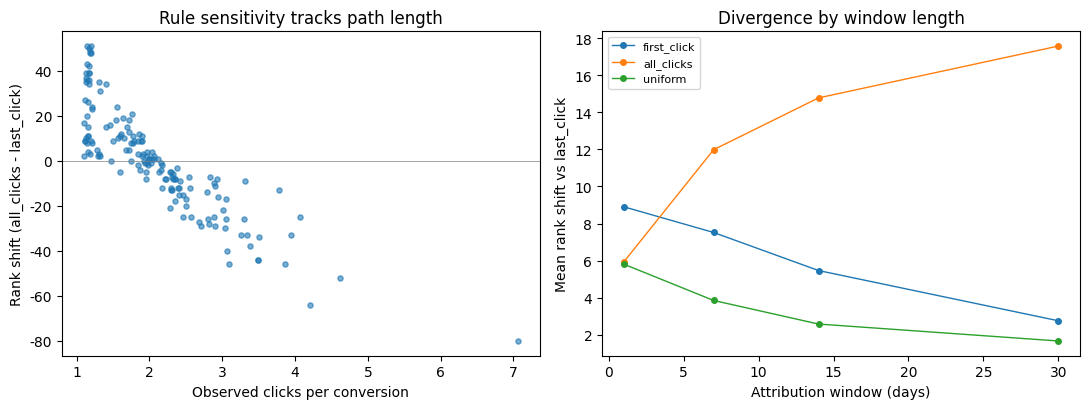

In [11]:
w30 = credit(WINDOWS[30]).copy()

pl = pd.read_sql_query(f"""
SELECT campaign,
       1.0 * COUNT(*) / COUNT(DISTINCT conversion_id) AS obs_clicks_per_conv,
       AVG(click_nb)                                 AS avg_true_click_nb
FROM attributed_clean WHERE gap <= {WINDOWS[30]} GROUP BY campaign
""", con)

m = w30.merge(pl, on='campaign')
m = m[m.last_click >= 200].copy()
for r in RULES:
    m[f'rk_{r}'] = m[r].rank(ascending=False, method='min')
m['rank_shift'] = m['rk_all_clicks'] - m['rk_last_click']

print(f'campaigns: {len(m)}')
print('\nspearman correlation of rank shift with path length:')
print(m[['rank_shift', 'obs_clicks_per_conv', 'avg_true_click_nb']]
      .corr(method='spearman').to_string(float_format='%.4f'))

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].scatter(m['obs_clicks_per_conv'], m['rank_shift'], s=14, alpha=0.6)
ax[0].axhline(0, color='gray', lw=0.5)
ax[0].set(xlabel='Observed clicks per conversion',
          ylabel='Rank shift (all_clicks - last_click)',
          title='Rule sensitivity tracks path length')

for r in ['first_click', 'all_clicks', 'uniform']:
    s = rank[(rank.min_credit == 200) & (rank.vs == r)].sort_values('window')
    ax[1].plot(s.window, s.mean_shift, marker='o', ms=4, lw=1, label=r)
ax[1].set(xlabel='Attribution window (days)',
          ylabel='Mean rank shift vs last_click',
          title='Divergence by window length')
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{BASE}/figures/module_b_ranking.png')
plt.show()

In [14]:
trunc = pd.read_sql_query("""
WITH pc AS (
  SELECT conversion_id, COUNT(*) AS n_rows, MAX(click_nb) AS cnb,
         MIN(click_pos) AS pos_min, MAX(click_pos) AS pos_max,
         MIN(timestamp) AS ts_min, MAX(conversion_timestamp) AS cts
  FROM attributed_clean GROUP BY conversion_id
)
SELECT
  CASE WHEN n_rows = cnb                      THEN 'complete'
       WHEN pos_min > 0 AND pos_max = cnb - 1  THEN 'prefix_missing'
       WHEN pos_min = 0 AND pos_max < cnb - 1  THEN 'suffix_missing'
       ELSE 'other' END AS pattern,
  COUNT(*) AS conversions, AVG(ts_min) AS avg_first_click_ts,
  AVG(cts) AS avg_conversion_ts, AVG(cnb) AS avg_true_clicks
FROM pc WHERE cnb >= 2 GROUP BY pattern
""", con)

obs = pd.read_sql_query("""
SELECT COUNT(*) AS observed_clicks,
       (SELECT SUM(cnb) FROM (SELECT MAX(click_nb) AS cnb FROM attributed
        GROUP BY conversion_id)) AS true_clicks
FROM attributed
""", con)

out = {
    'population': {
        'attributed_rows': 442424, 'attributed_conversions': 236331,
        'clean_rows': 439496, 'clean_conversions': 235510,
        'true_clicks_in_paths': int(obs.true_clicks[0]),
        'observed_share_of_path_clicks':
            float(obs.observed_clicks[0] / obs.true_clicks[0]),
        'single_click_conversions': 141010,
    },
    'rule_totals_by_window': tot.to_dict('records'),
    'path_truncation': trunc.to_dict('records'),
    'data_window_max_timestamp': 2671199,
    'campaign_credit_by_window': cc.to_dict('records'),
    'rank_agreement': rank.to_dict('records'),
    'rank_shift_vs_path_length': {
        'campaigns': int(len(m)),
        'min_credit': 200, 'window_days': 30,
        'spearman_obs_clicks': float(
            m['rank_shift'].corr(m['obs_clicks_per_conv'], method='spearman')),
        'spearman_true_click_nb': float(
            m['rank_shift'].corr(m['avg_true_click_nb'], method='spearman')),
    },
    'notes': [
        'All four rules are conditioned on attribution = 1, so the '
        'population is 236,331 conversions, not 435,810.',
        'Only 79.0% of the clicks recorded in click_nb appear as rows. '
        'Observed clicks form a contiguous run: of conversions with '
        'click_nb = 3 and two rows observed, 3,923 miss an end and 17 '
        'miss the middle. This is window truncation, not random sampling.',
        'suffix_missing conversions have mean conversion timestamp '
        '3,540,576, beyond the impression window maximum of 2,671,199.',
        'last_click and first_click lose a conversion entirely when the '
        'relevant end is truncated (8.7% and 8.9%). all_clicks and '
        'uniform degrade gradually.',
        'Rank shift between all_clicks and last_click is almost fully '
        'explained by path length (Spearman -0.909).',
    ],
}

with open(f'{BASE}/output/module_b.json', 'w') as fh:
    json.dump(out, fh, indent=2)
print('saved:', os.path.getsize(f'{BASE}/output/module_b.json'), 'bytes')

saved: 482789 bytes
